# **Preprocessing Data (Klasifikasi Time Series - Dataset BME)**

### 3.1 Import dan Ambil Data

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import joblib
df_train = pd.read_csv('BME_TRAIN.csv')
df_test = pd.read_csv('BME_TEST.csv')

print(f"Data Training: {df_train.shape}")
print(f"Data Testing: {df_test.shape}")

Data Training: (30, 129)
Data Testing: (8, 129)


### 3.2 Pisahkan Fitur dan Target

In [2]:
X_train = df_train.drop('target', axis=1)
y_train = df_train['target']

X_test = df_test.drop('target', axis=1)
y_test = df_test['target']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (30, 128)
y_train shape: (30,)
X_test shape: (8, 128)
y_test shape: (8,)


### 3.3 Cek Outliers

In [3]:
def count_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound)).sum().sum()
    return outliers

outliers_train = count_outliers_iqr(X_train)
outliers_test = count_outliers_iqr(X_test)

print(f"Jumlah outlier di data training SEBELUM penanganan: {outliers_train}")
print(f"Jumlah outlier di data testing SEBELUM penanganan: {outliers_test}")


Jumlah outlier di data training SEBELUM penanganan: 259
Jumlah outlier di data testing SEBELUM penanganan: 54


In [4]:
def handle_outliers_winsorization(data):
    data_copy = data.copy()
    
    Q1 = data_copy.quantile(0.25)
    Q3 = data_copy.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: nilai di bawah lower_bound diganti dengan lower_bound
    #          nilai di atas upper_bound diganti dengan upper_bound
    for col in data_copy.columns:
        data_copy[col] = data_copy[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    
    return data_copy

X_train = handle_outliers_winsorization(X_train)
X_test = handle_outliers_winsorization(X_test)

outliers_train_after = count_outliers_iqr(X_train)
outliers_test_after = count_outliers_iqr(X_test)

print(f"\nJumlah outlier di data training SETELAH penanganan: {outliers_train_after}")
print(f"Jumlah outlier di data testing SETELAH penanganan: {outliers_test_after}")



Jumlah outlier di data training SETELAH penanganan: 0


Jumlah outlier di data testing SETELAH penanganan: 31


### 3.4 Cek Duplikat Data

In [5]:
duplicates_train = df_train.duplicated().sum()
duplicates_test = df_test.duplicated().sum()

print(f"Duplikat di data training: {duplicates_train}")
print(f"Duplikat di data testing: {duplicates_test}")

if duplicates_train > 0:
    print(f"Menghapus {duplicates_train} duplikat di data training")
    df_train = df_train.drop_duplicates()
    X_train = df_train.drop('target', axis=1)
    y_train = df_train['target']

Duplikat di data training: 0
Duplikat di data testing: 0


### 3.5 Encoding Label Target

In [6]:
print("Label asli:")
print(f"  Unique values: {sorted(y_train.unique())}")
print(f"  Distribusi: \n{y_train.value_counts().sort_index()}")

# Cek apakah label sudah numerik
if y_train.dtype == 'object':
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder.transform(y_test)
else:
    print("Label sudah dalam format numerik, tidak perlu encoding")

Label asli:
  Unique values: [1, 2, 3]
  Distribusi: 
target
1    10
2    10
3    10
Name: count, dtype: int64
Label sudah dalam format numerik, tidak perlu encoding


### 3.6 Standarisasi Data dengan StandardScaler

In [7]:
print("Statistik SEBELUM standarisasi:")
print(f"  X_train - Mean: {X_train.values.mean():.4f}, Std: {X_train. values.std():.4f}")
print(f"  X_train - Min: {X_train.values.min():.4f}, Max: {X_train.values.max():.4f}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStatistik SETELAH standarisasi:")
print(f"  X_train_scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  X_train_scaled - Min: {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

Statistik SEBELUM standarisasi:
  X_train - Mean: 0.0528, Std: 0.6179
  X_train - Min: -1.3960, Max: 1.3700

Statistik SETELAH standarisasi:
  X_train_scaled - Mean: 0.000000, Std: 1.000000
  X_train_scaled - Min: -2.4950, Max: 2.8629


### 3.7 Visualisasi Perbandingan Sebelum dan Sesudah Scaling

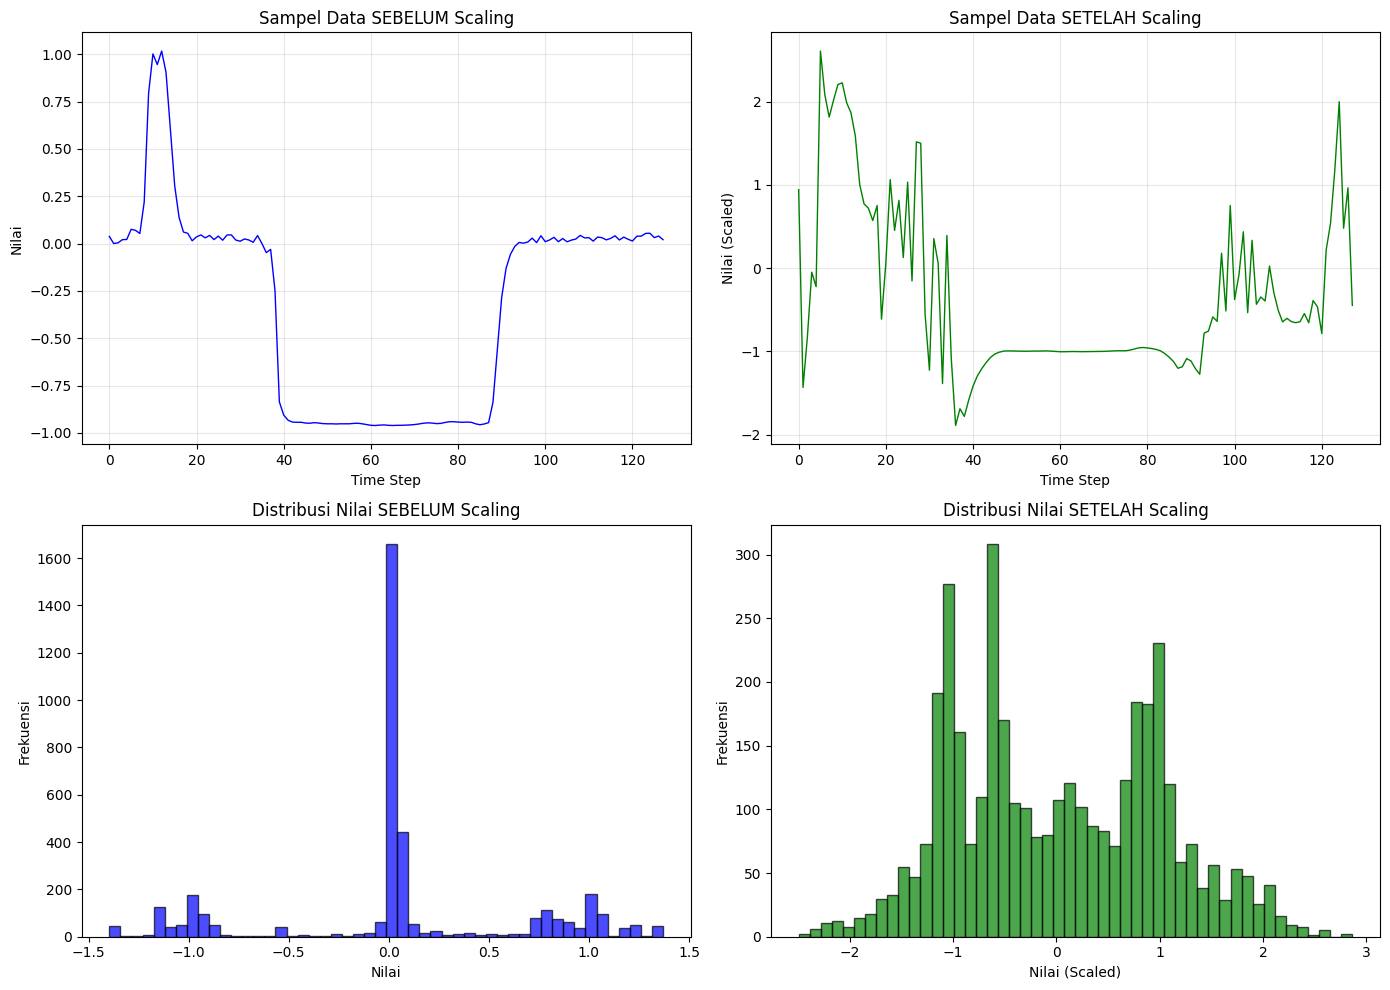

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sampel 1 data sebelum scaling
ax1 = axes[0, 0]
ax1.plot(X_train. iloc[0]. values, color='blue', linewidth=1)
ax1.set_title('Sampel Data SEBELUM Scaling')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Nilai')
ax1.grid(True, alpha=0.3)

# Sampel 1 data setelah scaling
ax2 = axes[0, 1]
ax2.plot(X_train_scaled[0], color='green', linewidth=1)
ax2.set_title('Sampel Data SETELAH Scaling')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Nilai (Scaled)')
ax2.grid(True, alpha=0.3)

# Distribusi nilai sebelum scaling
ax3 = axes[1, 0]
ax3.hist(X_train.values. flatten(), bins=50, color='blue', alpha=0.7, edgecolor='black')
ax3.set_title('Distribusi Nilai SEBELUM Scaling')
ax3.set_xlabel('Nilai')
ax3.set_ylabel('Frekuensi')

# Distribusi nilai setelah scaling
ax4 = axes[1, 1]
ax4.hist(X_train_scaled.flatten(), bins=50, color='green', alpha=0.7, edgecolor='black')
ax4.set_title('Distribusi Nilai SETELAH Scaling')
ax4.set_xlabel('Nilai (Scaled)')
ax4.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


In [9]:
joblib.dump(scaler, 'scaler_bme.pkl')
print("Scaler berhasil disimpan sebagai 'scaler_bme.pkl'")

Scaler berhasil disimpan sebagai 'scaler_bme.pkl'
